# Tehtävä:
Valitkaa tutkimuksenne kohteeksi haluamanne tietoaineisto. Kyseessä voi olla jokin verkon datapankeista
löytyvä tietoaineisto tai muulla tavoin (esim. web-louhinnan tekniikoin) kerätty aineisto.
Esimerkkejä verkossa saatavilla olevista aineistoista ja aineistokokoelmista:
- __[University of California Irvinen koneoppimisen tietovarasto](http://archive.ics.uci.edu/ml/datasets)__.
- __[Kagglen aineistopankki](https://www.kaggle.com/datasets)__.
- __[Helsinki Region Infoshare](http://www.hri.fi/fi/)__.
- __[Väestörekisterikeskuksen avoindata.fi-palvelu:](https://www.avoindata.fi/)__.
Voitte käyttää myös mitä tahansa muuta teitä kiinnostavaa aineistoa.
Projektityössä noudatetaan CRISP-DM-mallia. Tutkimuskysymykset saatte keksiä itse.
Työ alkaa tavoitteenasettelusta. Valitkaa aluksi teitä kiinnostavat tutkimuskysymykset: mitä ennalta
tuntematonta haluatte saada aineistostanne selville **(CRISP-DM-mallin vaihe 1)**?
Kuvatkaa aineistonne **(vaihe 2)** ja esikäsitelkää se **(vaihe 3)** valitsemienne analyysimenetelmien
vaatimaan muotoon. Analysoikaa aineisto soveltuvin menetelmin **(vaihe 4)**, tulkitkaa tulokset
**(vaihe 5)** ja kuvatkaa, millä tavoin tuloksia voi hyödyntää **(vaihe 6)**.

# Tuotokset:
Viimeisellä viikolla pidetään seminaaritilaisuus, jossa kukin tiimi esittelee projektinsa saavutukset.
Esityksen lisäksi tuotoksena palautetaan:
· linkki havainnolliseen ja esityskelpoiseen Jupyter Notebookina toteutettuun analyysiraporttiin,
jossa kuvataan ja toteutetaan tiedonlouhintaprosessin eteneminen CRISP-DMmallin
mukaisesti.

# Arviointi:
Projektityön perusteella voi saada 25% kurssin kokonaispistemäärästä. Työstä saatavaan pistemäärään
vaikuttavat seuraavat seikat:
· kysymyksenasettelun haastavuus ja omaleimaisuus
· aineiston soveltuvuus asetettuihin tutkimuskysymyksiin
· aineiston käsittelyn (keruu, esikäsittely, analyysi) tekninen oikeellisuus ja innovatiivisuus
· tulosten kuvaaminen ja oikea tulkinta sekä tehtyjen johtopäätösten perustelu
· dokumenttien ymmärrettävyys ja kattavuus
· seminaariesityksen laatu

# Business Understanding
The first phase is to understand the business problem that needs to be solved.
- What is the goal of the analysis?
- What are the requirements and constraints?
- What is the expected outcome?


### - Kesken -

# Data Understanding
The second phase is to collect and explore the data.
- What data is available? What are the characteristics of the data (variable types, value distributions etc.)?
- Are there any quality issues with the data (missing values, outliers, nonsensical values)?

In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('../datasets/Imdb_Movie_Dataset.csv', delimiter=',')

print(df.describe())
print(df.columns)

                 id  vote_average    vote_count       revenue       runtime  \
count  1.048575e+06  1.048575e+06  1.048575e+06  1.048575e+06  1.048575e+06   
mean   7.546888e+05  2.041560e+00  2.045584e+01  7.604112e+05  4.822610e+01   
std    4.207457e+05  3.097234e+00  3.315669e+02  1.944925e+07  6.057823e+01   
min    2.000000e+00  0.000000e+00  0.000000e+00 -1.200000e+01 -2.800000e+01   
25%    3.846625e+05  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
50%    8.183790e+05  0.000000e+00  0.000000e+00  0.000000e+00  2.300000e+01   
75%    1.140640e+06  5.000000e+00  1.000000e+00  0.000000e+00  8.900000e+01   
max    1.411041e+06  1.000000e+01  3.449500e+04  5.000000e+09  1.440000e+04   

             budget    popularity  
count  1.048575e+06  1.048575e+06  
mean   2.913232e+05  1.276393e+00  
std    5.319290e+06  7.889555e+00  
min    0.000000e+00  0.000000e+00  
25%    0.000000e+00  6.000000e-01  
50%    0.000000e+00  6.000000e-01  
75%    0.000000e+00  9.170000e-01  


# Data Preparation
 The third phase is to preprocess the data.
 - This includes cleaning the data, transforming the data, and selecting the relevant features.
  - These steps should be documented in such detail that they can be reproduced later.

In [13]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore


# Load dataset
df = pd.read_csv('../datasets/Imdb_Movie_Dataset.csv', delimiter=',')

# Check for missing values
print("\nMissing values before cleaning:")
print(df.isnull().sum())

# Drop irrelevant columns with excessive missing values
df.drop(columns=['tagline', 'keywords', 'spoken_languages', 'production_countries'], inplace=True, errors='ignore')

# Fill missing values in essential columns
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')  # Convert to datetime
df['release_date'] = df['release_date'].fillna(df['release_date'].mode()[0])  # Fill missing release dates with the most frequent value
df['genres'] = df['genres'].fillna('Unknown')
df['production_companies'] = df['production_companies'].fillna('Unknown')

# Drop remaining rows with missing values
df.dropna(inplace=True)

# Remove nonsensical values
df = df[(df['budget'] > 1000) & (df['revenue'] > 1000)]  # Remove unrealistic budget/revenue
df = df[(df['runtime'] >= 10) & (df['runtime'] <= 300)]  # Keep reasonable runtime

# Select relevant columns
title_mapping = df[['title']].copy()
df = df[['title', 'vote_average', 'vote_count', 'revenue', 'budget', 'runtime',
         'popularity', 'genres', 'production_companies']]

# Convert genres into binary columns (One-Hot Encoding)
genre_dummies = df['genres'].str.get_dummies(sep=', ')

# Join the genre_dummies with the original DataFrame, specifying suffixes to avoid column overlap
df = df.join(genre_dummies, rsuffix='_genre')

# Drop non-numeric columns if they exist
columns_to_drop = ['title', 'genres', 'production_companies']
df.drop(columns=[col for col in columns_to_drop if col in df.columns], inplace=True)


# Standardization
scaler = StandardScaler()
df[['budget', 'revenue', 'runtime', 'popularity', 'vote_count']] = scaler.fit_transform(
    df[['budget', 'revenue', 'runtime', 'popularity', 'vote_count']]
)

# Remove Outliers using Z-score
numerical_cols = ['vote_average', 'vote_count', 'revenue', 'budget', 'runtime', 'popularity']
df = df[(df[numerical_cols].apply(zscore).abs() < 3).all(axis=1)]  # Keep rows within 3 standard deviations

# Feature Engineering - Log Transformation
df['log_budget'] = np.log1p(df['budget'])
df['log_revenue'] = np.log1p(df['revenue'])
df['log_popularity'] = np.log1p(df['popularity'])

# Drop original columns after log transformation
df.drop(columns=['budget', 'revenue', 'popularity'], inplace=True)

# Prepare Data for Modeling
X_rating = df.drop(columns=['vote_average'])
y_rating = df['vote_average']

X_genre = df.drop(columns=['vote_average'])
y_genre = genre_dummies  # Use multi-label classification

# Ensure X_genre and y_genre have the same number of samples
X_genre, y_genre = X_genre.align(y_genre, join='inner', axis=0)

X_clustering = df[['runtime', 'log_popularity'] + list(genre_dummies.columns)]



# Print dataset shape and first few rows after cleaning
print("\nFinal dataset shape:", df.shape)

# Display a small sample of the cleaned dataset
print("\nSample of cleaned dataset (limited columns for readability):")
print(df.head())  # Removed references to non-existing 'title' or 'genres'


Missing values before cleaning:
id                           0
title                       13
vote_average                 0
vote_count                   0
status                       0
release_date            181817
revenue                      0
runtime                      0
adult                        0
budget                       0
imdb_id                 487595
original_language            0
original_title              13
overview                215824
popularity                   0
tagline                 895847
genres                  414972
production_companies    568428
production_countries    463497
spoken_languages        440662
keywords                755953
dtype: int64

Final dataset shape: (8956, 26)

Sample of cleaned dataset (limited columns for readability):
     vote_average  vote_count   runtime  Action  Adventure  Animation  Comedy  \
245         8.242    2.999314  0.900528       0          0          0       1   
247         7.662    2.995643  1.444262       

# Modeling
For movie rating prediction, Linear Regression and Random Forest were used to compare performance. Genre prediction was conducted using Random Forest, while a basic recommendation system was implemented through clustering. .



## Part 1: Movie rating prediction
### 1.1 Linear Regression 

Linear regression is a great starting point for predicting movie ratings because it is **simple, interpretable, and efficient**. It directly shows how each feature (budget, runtime, popularity, etc.) impacts the rating, works well with large datasets, and is computationally lightweight compared to complex models. The code cleans the data, splits it into training and test sets, trains a linear model, and evaluates its performance using RMSE and R². Finally, a scatter plot helps visualize how accurate the predictions are.  

1. **Selecting Numeric Features:**  
   `X_rating_numeric`: Categorical and text-based columns are removed because linear regression works only with numerical features.  
   <br>  
2. **Splitting the Data into Training and Test Sets:**  
   `test_size=0.2`: 20% of the data is used as the test set.  
   `random_state=42`: Ensures reproducible results.  
   <br>  
3. **Training the Linear Model:**  
   `model = LinearRegression()`: Creates a linear model.  
   `model.fit(X_train, y_train)`: Fits the model to the training data.  
   <br>  
4. **Prediction and Error Evaluation:**  
   `y_pred = model.predict(X_test)`: Makes predictions on the test data.  
   `np.sqrt(mean_squared_error(y_test, y_pred))`: Calculates MSE and converts it to RMSE for easier interpretation.  
   `r2_score(y_test, y_pred)`: Computes the R² score, indicating how well the model explains data variance.  
   <br>  
5. **Visualizing the Results:**  
   A scatter plot shows how well the predicted ratings match the actual ratings.  
   The red dashed line represents the ideal line (perfect predictions).  
   If the points are scattered and do not follow the line, the model does not predict well.  

Root Mean Squared Error: 0.8348
R-squared Score: 0.2554


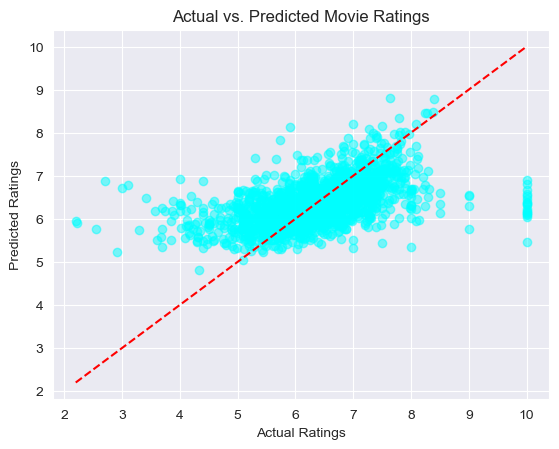

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Remove text-based columns to keep only numerical features
X_rating_numeric = X_rating.select_dtypes(include=["number"])

# Split the data into training and test sets
X_train, X_test_lr, y_train, y_test_lr = train_test_split(X_rating_numeric, y_rating, test_size=0.2, random_state=42)

# Initialize and train the linear regression model
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model_lr.predict(X_test_lr)

# Evaluate 
rmse = np.sqrt(mean_squared_error(y_test_lr, y_pred))
r2 = r2_score(y_test_lr, y_pred)

print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"R-squared Score: {r2:.4f}")

# visualization
plt.scatter(y_test_lr, y_pred, alpha=0.5, color='cyan')
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs. Predicted Movie Ratings")
plt.plot([min(y_test_lr.values), max(y_test_lr.values)], [min(y_test_lr.values), max(y_test_lr.values)], color='red', linestyle='dashed')
plt.show()


### 1.2 Random forest regressoria
Random Forest Regressor, a decision tree-based machine learning model for regression analysis.

`test_size=0.4`:  40% of the data is allocated to the test set, while the remaining 60% is used for training. Tested 0.2, 0.3, and 0.4, and 0.4 gave the best R² score.
    
`model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)` 
n_estimators=100 → Uses 100 decision trees to build the forest. A higher number of trees can improve stability and accuracy.
random_state=42 → Sets the random seed to 42 to ensure reproducible results across runs.
max_depth=10 → Limits the maximum depth of each decision tree to 10. 

Root Mean Squared Error: 0.7571
R-squared Score: 0.3994


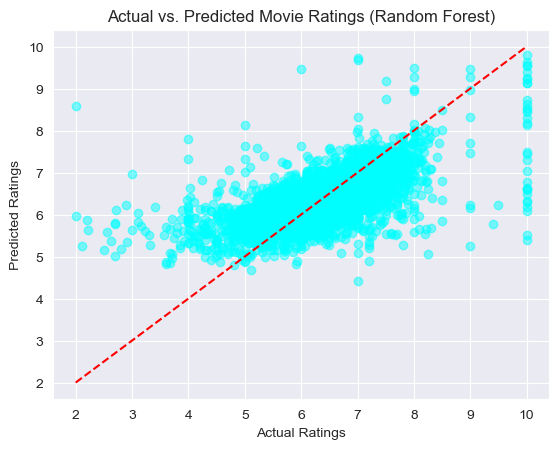

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

X_rating_numeric = X_rating.select_dtypes(include=["number"])

X_train, X_test_rf, y_train, y_test_rf = train_test_split(X_rating_numeric, y_rating, test_size=0.4, random_state=42)

# Random Forest Regressoria
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
model_rf.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model_rf.predict(X_test_rf)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test_rf, y_pred))
r2 = r2_score(y_test_rf, y_pred)

print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"R-squared Score: {r2:.4f}")

# visualization
plt.scatter(y_test_rf, y_pred, alpha=0.5, color='cyan')
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs. Predicted Movie Ratings (Random Forest)")
plt.plot([min(y_test_rf.values), max(y_test_rf.values)], [min(y_test_rf.values), max(y_test_rf.values)], color='red', linestyle='dashed')
plt.show()

## Part 2: Genre prediction
- The dataset is split into training and testing sets using train_test_split.
- X_genre contains the features, and y_genre contains the target labels.
- test_size=0.3 means 30% of the data is used for testing, and 70% for training.
- random_state=42 ensures reproducibility of the split.

- A Random Forest Classifier is trained on the training set.
- n_estimators=100 means 100 decision trees are used in the forest.

- The model is used to predict genres on the test set.
- The report includes precision, recall, and F1-score for each genre.

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from matplotlib import pyplot as plt
from sklearn.tree import plot_tree
import seaborn as sns
from sklearn.model_selection import GridSearchCV

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_genre, y_genre, test_size=0.3, random_state=42)

# Train Random Forest Classifier
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, None],
    "min_samples_split": [2, 5]
}

# Grid search for hyperparameter tuning
grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=2, scoring="f1_micro")
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

# Predict genres on test set
y_pred = best_model.predict(X_test)



print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=y_test.columns, zero_division=0))

Accuracy: 0.9438034983252698

Classification Report:
                  precision    recall  f1-score   support

         Action       1.00      1.00      1.00       636
      Adventure       1.00      1.00      1.00       393
      Animation       1.00      0.82      0.90       129
         Comedy       1.00      1.00      1.00      1013
          Crime       1.00      1.00      1.00       397
    Documentary       1.00      0.82      0.90        44
          Drama       1.00      1.00      1.00      1296
         Family       1.00      0.98      0.99       263
        Fantasy       1.00      0.93      0.97       215
        History       1.00      0.89      0.94       133
         Horror       1.00      0.98      0.99       321
          Music       1.00      0.79      0.89       107
        Mystery       1.00      0.94      0.97       239
        Romance       1.00      1.00      1.00       504
Science Fiction       1.00      0.97      0.99       237
       TV Movie       0.00      0

Most genres have a precision and recall of 1.00, meaning the model classifies them almost perfectly. However, some genres have a lower precision and recall, such as 'TV Movie' and 'Foreign'. This could be due to the low number of samples for these genres, making it harder for the model to learn their patterns.


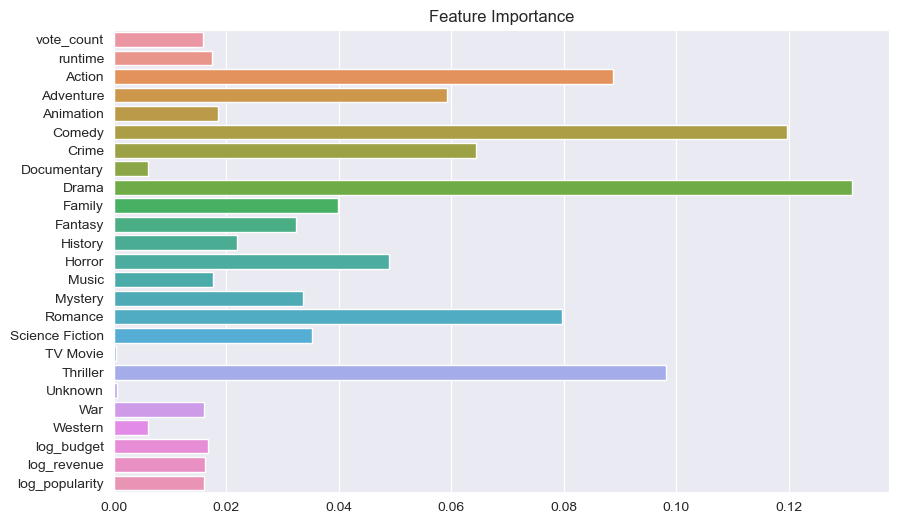

In [17]:
# Plot feature importance
importances = best_model.feature_importances_
features = X_train.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()

From the plot, we can see that the most important features are drama and comedy. These features have the highest importance scores, indicating that they play a crucial role in predicting the genres of movies. This suggests that these genres have distinct patterns that the model can learn effectively.

## Part 3: Recommending System

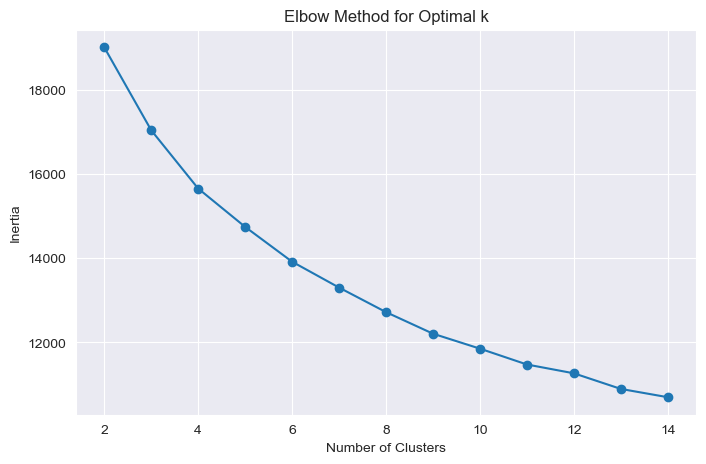

                        title  cluster
245                Green Book      0.0
247                 Cast Away      0.0
248                     X-Men      2.0
253                     Taken      2.0
255          The Big Lebowski      1.0
257        Dead Poets Society      0.0
260                  Die Hard      2.0
261          Now You See Me 2      2.0
262                Home Alone      4.0
265  The Theory of Everything      5.0
['Teenage Mutant Ninja Turtles: Out of the Shadows', "Me Against You: Mr. S's Vendetta", 'Care Bears Movie II: A New Generation', 'The Garbage Pail Kids Movie', 'Cheburashka']


In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = df.join(title_mapping)
# Choose number of clusters using the Elbow Method
inertia = []
K_range = range(2, 15)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_clustering)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

# Train K-Means with the selected k
optimal_k = 6
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df, X_clustering = df.align(X_clustering, join='inner', axis=0)
df.loc[X_clustering.index, 'cluster'] = kmeans.fit_predict(X_clustering)


# Display sample movies and their assigned clusters
print(df[['title', 'cluster']].head(10))

def recommend_movies(movie_title, df, title_mapping, n=5):
    # Check if the movie title exists in title_mapping
    if movie_title not in title_mapping['title'].values:
        return "Movie not found in the dataset."

    # Find the cluster of the given movie (use df, which contains the cluster labels)
    movie_cluster = df[df['title'] == movie_title]['cluster'].values[0]

    # Get other movies from the same cluster
    similar_movies = df[df['cluster'] == movie_cluster].sample(n=n)['title'].tolist()

    return similar_movies

# Example: Get recommendations for a movie
print(recommend_movies("Home Alone", df, title_mapping, n=5))

# Evaluation
The fifth phase is to evaluate the model.
- How well does the model perform?
 - Does it meet the business requirements?

### Movie Rating Evaluation

When we first began planning, we hypothesized that Linear Regression would be a good starting point for predicting movie ratings, using numerical variables like budget and revenue. This approach is often a reasonable choice when we expect linear relationships between input features and the target variable. However, after training the model on a test set comprising 20% of the data, we found that the predictions from Linear Regression were unexpectedly low, suggesting the model was struggling with the complexity of analyzing the data in a way that meets our needs.

As a result, we turned to Random Forest Regression, a model capable of capturing non-linear relationships and complex interactions between features. This model was tested on a larger test set comprising 40% of the data, allowing for a broader evaluation of its predictive capabilities. When tested, we saw that Random Forest better suited the task of predicting movie ratings. We can therefore assume that movie ratings are influenced by a combination of factors that don’t follow a simple linear pattern.

Linear Regression Evaluation Metrics:
Root Mean Squared Error (RMSE): 0.8348
R-squared Score: 0.2554

Random Forest Evaluation Metrics:
Root Mean Squared Error (RMSE): 0.7571
R-squared Score: 0.3994


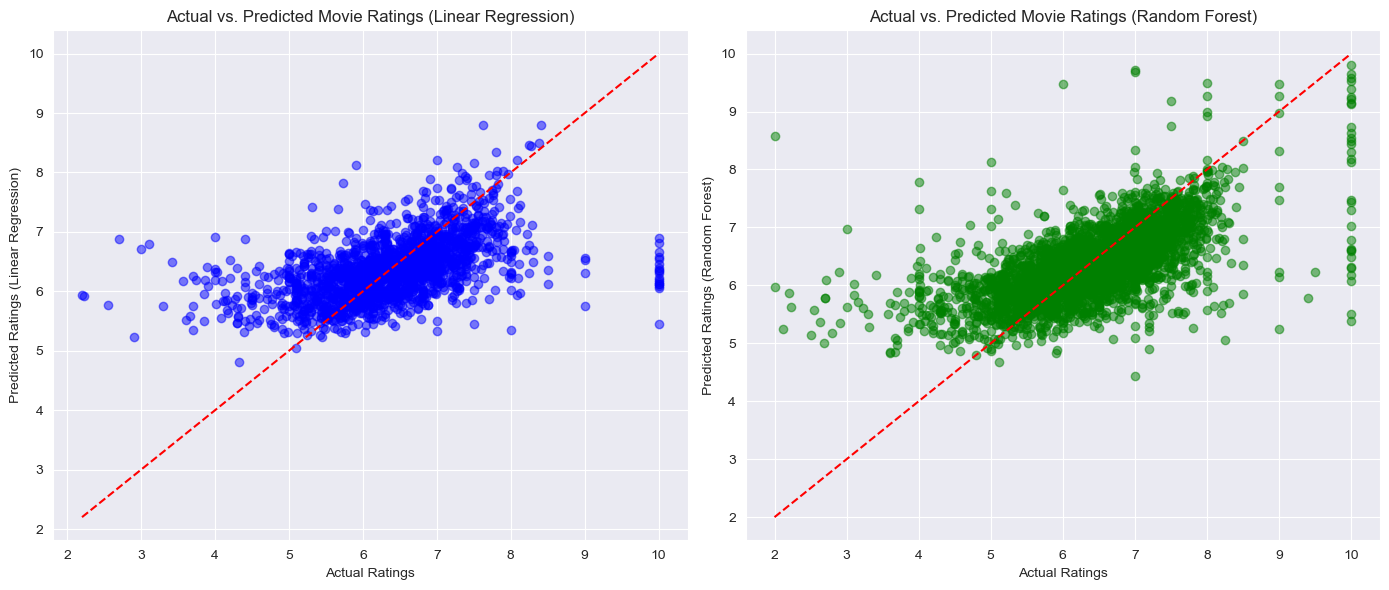

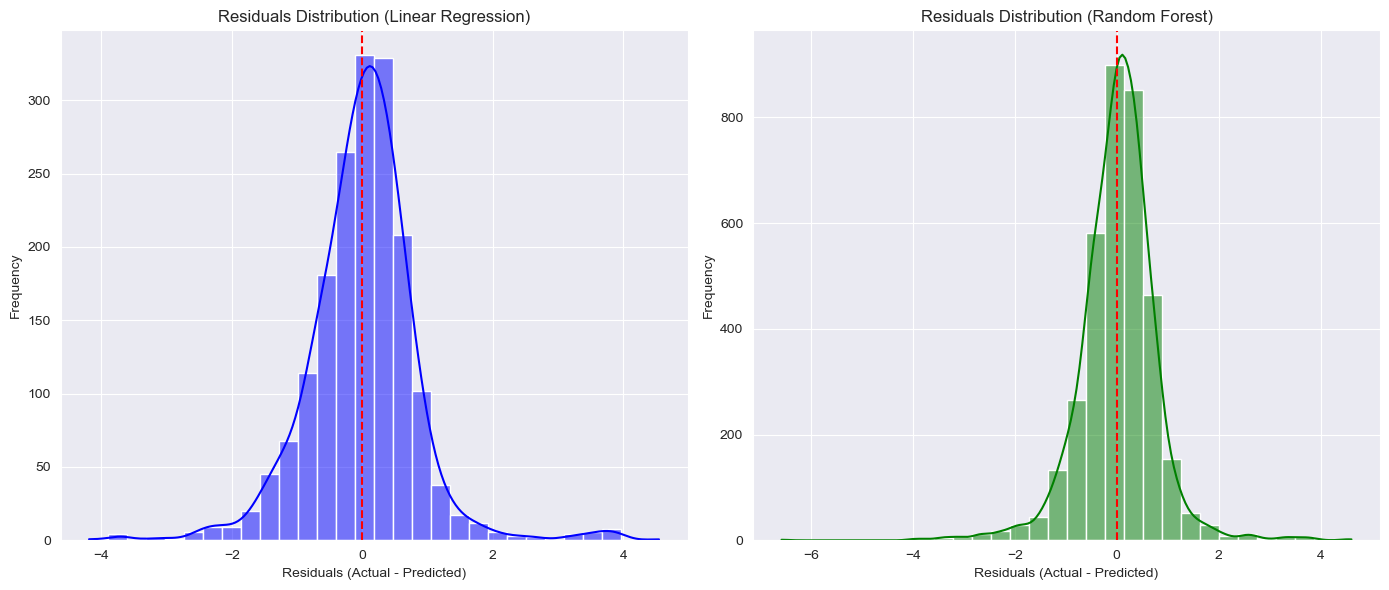

In [19]:
y_pred_lr = model_lr.predict(X_test_lr)
y_pred_rf = model_rf.predict(X_test_rf)

rmse_lr = np.sqrt(mean_squared_error(y_test_lr, y_pred_lr))
r2_lr = r2_score(y_test_lr, y_pred_lr)

rmse_rf = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))
r2_rf = r2_score(y_test_rf, y_pred_rf)

print("Linear Regression Evaluation Metrics:")
print(f"Root Mean Squared Error (RMSE): {rmse_lr:.4f}")
print(f"R-squared Score: {r2_lr:.4f}")
print("\nRandom Forest Evaluation Metrics:")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.4f}")
print(f"R-squared Score: {r2_rf:.4f}")

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_test_lr, y_pred_lr, alpha=0.5, color='blue')
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings (Linear Regression)")
plt.title("Actual vs. Predicted Movie Ratings (Linear Regression)")
plt.plot([min(y_test_lr), max(y_test_lr)], [min(y_test_lr), max(y_test_lr)], color='red', linestyle='dashed')

plt.subplot(1, 2, 2)
plt.scatter(y_test_rf, y_pred_rf, alpha=0.5, color='green')
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings (Random Forest)")
plt.title("Actual vs. Predicted Movie Ratings (Random Forest)")
plt.plot([min(y_test_rf), max(y_test_rf)], [min(y_test_rf), max(y_test_rf)], color='red', linestyle='dashed')

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))

residuals_lr = y_test_lr - y_pred_lr
plt.subplot(1, 2, 1)
sns.histplot(residuals_lr, bins=30, kde=True, color="blue")
plt.axvline(0, color="red", linestyle="dashed")
plt.xlabel("Residuals (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Residuals Distribution (Linear Regression)")

residuals_rf = y_test_rf - y_pred_rf
plt.subplot(1, 2, 2)
sns.histplot(residuals_rf, bins=30, kde=True, color="green")
plt.axvline(0, color="red", linestyle="dashed")
plt.xlabel("Residuals (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Residuals Distribution (Random Forest)")

plt.tight_layout()
plt.show()


#### Linear model
RMSE: 0.8348
R² Score: 0.2554

This indicates that the model explains only 25% of the variance in movie ratings. In other words, it predicts the correct rating correctly only about 1 out of 4 times on average, with relatively large prediction errors.


#### Random Forest
RMSE: 0.7571
R² Score: 0.3994

Although still under 50%, the Random Forest model demonstrates a noticeably better prediction rate compared to the Linear Regression model. It explains around 40% of the variance in movie ratings, which indicates improved accuracy in predictions, especially when compared to the linear model's ability to explain only 25%.


#### Residual Distribution
Both models show a bell-shaped residual distribution, indicating symmetrical errors. The residuals range from -2 to 2, with a notable concentration around 0, meaning that most predictions are close to the actual ratings.

The residual represents the difference between the actual rating and the predicted rating. A residual close to 0 indicates that the model's prediction is very close to the actual value, while values farther from 0 (either positive or negative) show where the model's prediction deviates from the true rating.

The Random Forest model exhibits a steeper curve, with fewer extreme errors and a more balanced distribution overall. While both models show a slight positive bias in their predictions, this bias is slightly more pronounced in the Linear Regression model.

#### Improving the models
Since the prediction accuracy is still relatively low, there are few ways to enhance the model’s performance. For example:

- Adding More Relevant Features
Including features such as director and actors could improve the model's accuracy. These features often have strong correlations with movie ratings and audience preferences, potentially providing more context for the predictions.

- Trying Advanced Models
Advanced models like Gradient Boosting Machines (GBM) or XGBoost are known to handle complex, non-linear relationships between features and could outperform Random Forest on this task, especially when fine-tuned.

### Movie Genre Predictions

In this analysis, we aimed to evaluate how well our model could predict the genre of a movie. We selected the Random Forest Classifier for its ability to handle complex, non-linear relationships between features and its strong performance across a variety of classification tasks.

After training the model, we evaluated its performance using several key metrics: precision, recall, and F1 score. These metrics allowed us to understand how accurately the model can predict each genre, as well as the balance between false positives and false negatives.

- Precision refers to how many of the predicted genres are actually correct.
- Recall measures how many of the actual genres were correctly identified.
- F1 Score provides a balanced measure that combines both precision and recall, useful when there is an uneven class distribution.

C:\Users\petra\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


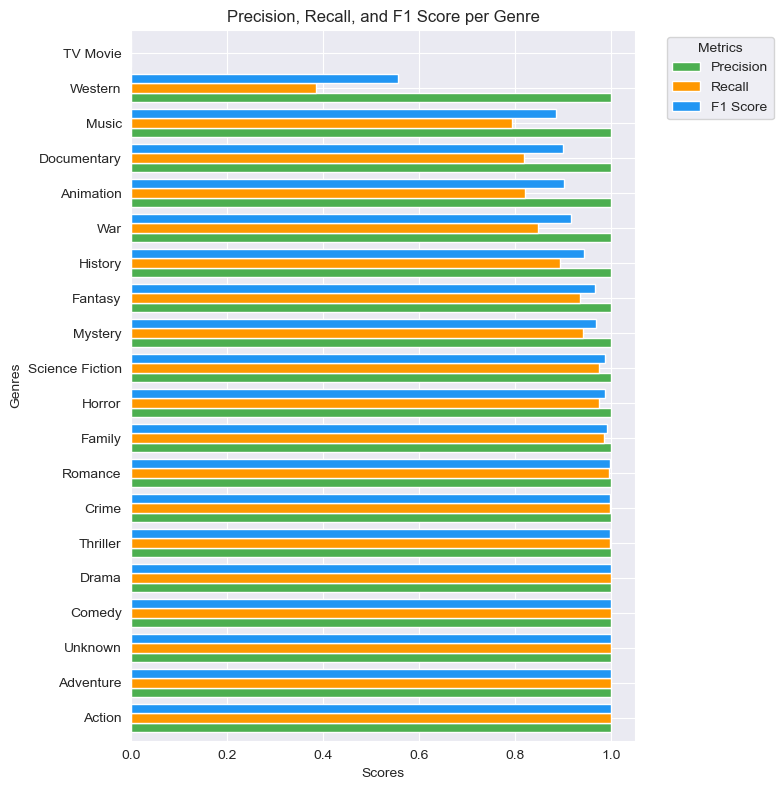

In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate Precision, Recall, F1 for each genre
precision = precision_score(y_test, y_pred, average=None)
recall = recall_score(y_test, y_pred, average=None)
f1 = f1_score(y_test, y_pred, average=None)

# Create a DataFrame to display the results for each genre
results_df = pd.DataFrame({
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1
}, index=y_test.columns)

# Sort the results by F1 Score to identify the best recognized genres
results_df_sorted = results_df.sort_values(by='F1 Score', ascending=False)

# Plot Precision, Recall, and F1 scores for each genre
fig, ax = plt.subplots(figsize=(8, 8))

# Create a grouped horizontal bar chart for Precision, Recall, and F1 Score with wider bars
results_df_sorted.plot(kind='barh', ax=ax, color=['#4CAF50', '#FF9800', '#2196F3'], width=0.8)  # Increased width to make bars thicker

# Set chart labels and title
ax.set_ylabel('Genres')
ax.set_xlabel('Scores')
ax.set_title('Precision, Recall, and F1 Score per Genre')

# Adjust legend to appear outside of the plot
ax.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')

# Tight layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()


#### Metrics Overview
The model has shown strong performance across most genres, with certain genres achieving perfect scores. Specifically, genres such as Action, Adventure, Unknown, Comedy, and Drama have all reached perfect precision, recall, and F1 scores of 1.0. This indicates that the model consistently recognizes these genres with no false positives or false negatives.

Key Observations:
- Action, Adventure, Unknown, Comedy, and Drama: These genres are the most successfully recognized by the model, achieving 1.0 scores across precision, recall, and F1. This means the model is able to correctly classify these genres with no errors.

- Other Genres: Some genres like TV Movie, Western, and Music show lower recall scores. TV Movie, in particular, has a recall of 0.0, suggesting that the model struggles to identify this genre correctly, likely due to the very small number of samples present in the dataset.

### Recommending System
In an ideal recommendation system, user behavior data (such as ratings, interactions, or preferences) is typically used to provide personalized movie suggestions. However, in this project, we did not have matching user-specific data that would allow us to create a truly personalized recommendation model.

Instead, we focused on a more general recommendation approach using the KMeans clustering algorithm. The idea behind this is to recommend movies that are similar to each other based on their inherent features, such as genre and rating. These clusters represent groups of movies that share common characteristics, so recommending movies within the same cluster can still lead to meaningful suggestions.

Once the clusters were created, we used the clustering labels to recommend similar movies. For example, when a user asks for recommendations based on a specific movie (e.g., "Home Alone"), the system can identify the cluster that "Home Alone" belongs to and recommend other movies in that same cluster.

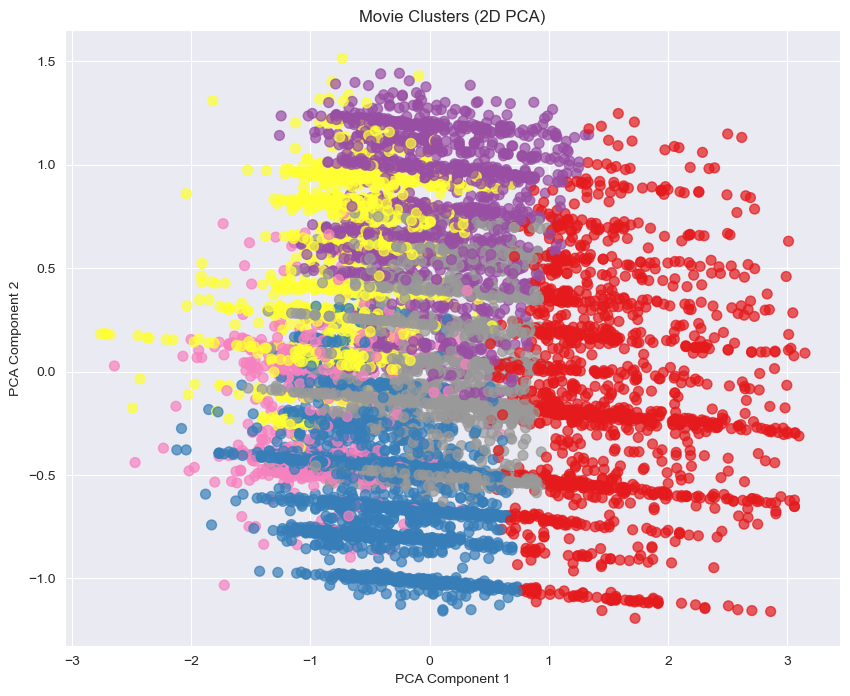

In [24]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clustering)

plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'], cmap='Set1', s=50, alpha=0.7)
plt.title('Movie Clusters (2D PCA)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.show()


#### Visualizing the Movie Clusters
To gain a deeper understanding of how movies are grouped into clusters, we use Principal Component Analysis (PCA) graph. PCA is a technique used to reduce the dimensionality of the feature space, making it easier to visualize high-dimensional data in a 2D plot. The goal of this visualization is to provide a clearer view of how movies are distributed across clusters based on their features.

In the plot:
- Each point represents a movie.
- Color coding indicates the different clusters identified by the KMeans algorithm. Each color corresponds to a distinct cluster of movies that share similar characteristics.

What the Plot Shows:

- Cluster Distribution: Ideally, if the clustering is effective, movies within the same cluster (represented by the same color) should appear closely grouped together. The separation between clusters suggests that the movies in each group are distinct in terms of their features (such as genre, rating, etc.).

- Overlapping Points: However, the plot also reveals some points that appear misplaced or within the "wrong" clusters. For instance, a purple point might appear within the blue cluster. This overlap happens because certain movies share similar characteristics (like genre or style) with other clusters. As a result, they are positioned in the middle of a neighboring cluster, causing some "cross-cluster" overlap.



# Deployment
 The final phase is to deploy the model.
 - How will the model be used in practice?
   - How will the results be communicated?
      - This phase may involve creating a recommendation of how to use the model in practice, or what to do next
